In [1]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import json


from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

In [ ]:
# ── DATA DIRECTORY ──────────────────────────────────────────────────────────
# Update this path if you cloned the repo to a different location.
# In WSL, your OneDrive Documents typically maps to:
DATA_DIR = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22"
DESEQ2_DIR = f"{DATA_DIR}/DeSeq2"
TPM_DIR    = f"{DATA_DIR}/Arquivos brutos/TPM"
GENOME_DIR = f"{DATA_DIR}/Arquivos brutos/genomes_9a5c_temecula1"


In [2]:
BASE_DIR = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results"

DICT_PATH = os.path.join(BASE_DIR, "dictionary_2_level.csv")

CACHE_FILE = "go_ancestor_cache.json"

# Load cache if exists
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, "r") as f:
        ancestor_cache = json.load(f)
else:
    ancestor_cache = {}

In [3]:
def get_ancestors(go_id):
    
    if go_id in ancestor_cache:
        return ancestor_cache[go_id]
    
    number = go_id.replace("GO:", "")
    
    url = (
        "https://www.ebi.ac.uk/QuickGO/services/ontology/go/terms/GO%3A"
        + number +
        "/ancestors?relations=is_a%2Cpart_of%2Coccurs_in%2Cregulates"
    )
    
    try:
        r = requests.get(url, headers={"Accept": "application/json"})
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        print(f"Error fetching {go_id}: {e}")
        ancestor_cache[go_id] = []
        return []
    
    ancestors = []
    
    for res in data.get("results", []):
        ancestors.extend(res.get("ancestors", []))
    
    ancestor_cache[go_id] = ancestors
    return ancestors

In [4]:
def load_GO_dictionary_with_category(path):
    df = pd.read_csv(path, header=None)
    
    # Force column names explicitly
    df.columns = ["level", "category_name", "GO_id", "term", "relation"]
    
    df = df[df["relation"] == "is_a"]
    
    go_to_term = dict(zip(df["GO_id"], df["term"]))
    
    category_map = {
        "biological_process": "P",
        "molecular_function": "F",
        "cellular_component": "C"
    }
    
    go_to_category = {
        go: category_map.get(cat_name, "NA")
        for go, cat_name in zip(df["GO_id"], df["category_name"])
    }
    
    return go_to_term, go_to_category

In [5]:
go_dict, go_category = load_GO_dictionary_with_category(DICT_PATH)

print(set(go_category.values()))

{'P', 'F', 'C'}


In [6]:
print(list(go_category.items())[:5])

[('GO:0051179', 'P'), ('GO:0009987', 'P'), ('GO:0001906', 'P'), ('GO:0009758', 'P'), ('GO:0006794', 'P')]


In [7]:
def load_GO_enrichment(file):
    df = pd.read_csv(file)
    
    # Keep only significant terms (optional threshold)
    df = df[df["p_adj"] < 0.05]
    
    go_pvals = dict(zip(df["go_term"], df["p_adj"]))
    go_names = dict(zip(df["go_term"], df["go_description"]))
    
    return go_pvals, go_names

In [8]:
def map_to_2nd_level(go_pvals, go_dict, go_category):
    
    term_pvals = defaultdict(list)
    term_category = {}
    
    valid = set(go_dict.keys())
    
    for go, pval in go_pvals.items():
        
        # Always include self + ancestors
        all_candidates = [go] + get_ancestors(go)
        
        for anc in all_candidates:
            if anc in valid:
                
                term = go_dict[anc]
                cat = go_category.get(anc, "NA")
                
                term_pvals[term].append(pval)
                
                # 🔥 ALWAYS assign category if valid
                if cat != "NA":
                    term_category[term] = cat
    
    term_best = {term: min(pvals) for term, pvals in term_pvals.items()}
    
    return term_best, term_category

In [9]:
# print(term_category)

In [10]:
def build_term_category_map(go_dict, go_category):
    term_category = {}
    
    for go, term in go_dict.items():
        cat = go_category.get(go, "NA")
        term_category[term] = cat
    
    return term_category

term_category = build_term_category_map(go_dict, go_category)

In [11]:
def build_signed_column(go_up, go_down, go_dict, go_category):
    
    up_terms, up_cat = map_to_2nd_level(go_up, go_dict, go_category)
    down_terms, down_cat = map_to_2nd_level(go_down, go_dict, go_category)
    
    term_scores = {}
    term_category = {}
    
    # UP → positive
    for term, p in up_terms.items():
        term_scores[term] = -np.log10(p)
        term_category[term] = up_cat.get(term, "NA")
    
    # DOWN → negative
    for term, p in down_terms.items():
        score = -np.log10(p) * (-1)
        
        if term in term_scores:
            if abs(score) > abs(term_scores[term]):
                term_scores[term] = score
        else:
            term_scores[term] = score
        
        # ensure category exists
        if term not in term_category:
            term_category[term] = down_cat.get(term, "NA")
    
    return term_scores, term_category

In [12]:
all_columns = {}
global_term_category = {}

for comp in os.listdir(BASE_DIR):
    
    comp_path = os.path.join(BASE_DIR, comp)
    
    if not os.path.isdir(comp_path):
        continue
    
    files = [f for f in os.listdir(comp_path) if "GO_enrichment_up_in" in f]
    
    if len(files) != 2:
        continue
    
    try:
        cond_A, cond_B = comp.split("_vs_")
    except:
        continue
    
    file_A = [f for f in files if cond_A in f][0]
    file_B = [f for f in files if cond_B in f][0]
    
    go_up, _ = load_GO_enrichment(os.path.join(comp_path, file_A))
    go_down, _ = load_GO_enrichment(os.path.join(comp_path, file_B))
    
    col, term_cat = build_signed_column(go_up, go_down, go_dict, go_category)
    
    all_columns[comp] = col

    # 🔥 MOVE THIS INSIDE THE LOOP
    for t, c in term_cat.items():
        if c != "NA":
            global_term_category[t] = c

In [13]:
print(global_term_category)

{'metabolic_process': 'P', 'structural_molecule_activity': 'F', 'organelle': 'C', 'cellular_process': 'P', 'protein-containing_complex': 'C', 'catalytic_activity': 'F', 'binding': 'F', 'transporter_activity': 'F', 'localization': 'P', 'membrane': 'C', 'toxin_activity': 'F', 'cellular_component_organization_or_biogenesis': 'P', 'translation_regulator_activity': 'F', 'biological_regulation': 'P'}


In [14]:
df = pd.DataFrame(all_columns).fillna(0)

In [15]:
# df = df.loc[(df.abs() > 1).any(axis=1)]  # keep meaningful signals
df_bp = df.loc[[t for t in df.index if global_term_category[t] == "P"]]
df_mf = df.loc[[t for t in df.index if global_term_category[t] == "F"]]
df_cc = df.loc[[t for t in df.index if global_term_category[t] == "C"]]

In [16]:
def cluster_rows(d):
    if len(d) <= 1:
        return d
    Z = linkage(d, method="average", metric="euclidean")
    return d.iloc[leaves_list(Z)]

df_bp = cluster_rows(df_bp)
df_mf = cluster_rows(df_mf)
df_cc = cluster_rows(df_cc)

In [17]:
df_ordered = pd.concat([df_bp, df_mf, df_cc])

In [22]:
category_colors = {
    "P": "#e95050",   # biological process (red-ish)
    "F": "#4e904a",   # molecular function (green-ish)
    "C": "#3367e1"    # cellular component (blue-ish)
}

row_colors = df_ordered.index.map(
    lambda x: category_colors.get(global_term_category.get(x, "NA"), "#cccccc")
)

custom_cmap = LinearSegmentedColormap.from_list(
    "green_gray_orange",
    [
        (0.0, "#385c42"),   # green (down)
        (0.5, "#d6d4d4"),   # gray (zero)
        (1.0, "#c77a30")    # orange/yellow (up)
    ]
)

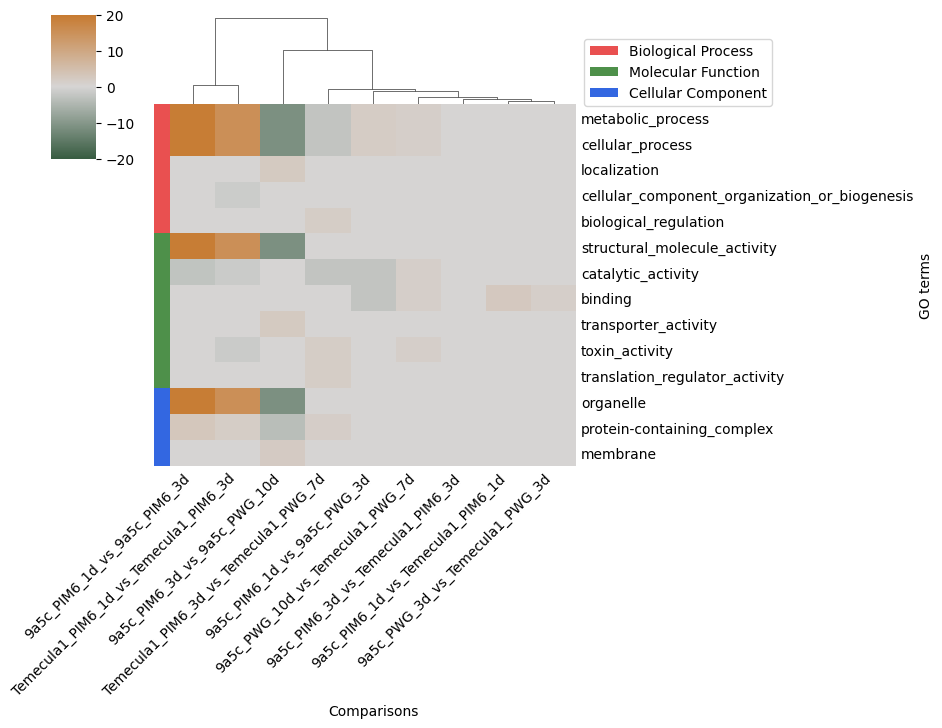

In [29]:
# g = sns.clustermap(
#     df,
#     cmap=custom_cmap,
#     center=0,
#     vmin=-20,
#     vmax=20,
#     linewidths=0.0,
#     row_cluster=True,
#     col_cluster=True,   # keep comparisons fixed
#     row_colors=row_colors,
#     figsize=(9, 8)
# )


g = sns.clustermap(
    df_ordered,
    cmap=custom_cmap,
    center=0,
    vmin=-20,
    vmax=20,
    row_cluster=False,   # IMPORTANT
    col_cluster=True,
    row_colors=row_colors,
    figsize=(9,8)
)


g.ax_heatmap.set_xlabel("Comparisons")
g.ax_heatmap.set_ylabel("GO terms")
g.ax_heatmap.tick_params(axis='both', length=0)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=10)

legend_elements = [
    Patch(facecolor="#e95050", label="Biological Process"),
    Patch(facecolor="#4e904a", label="Molecular Function"),
    Patch(facecolor="#3367e1", label="Cellular Component")
]

g.ax_heatmap.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.5, 1.2)
)

# plt.tight_layout()
# plt.savefig("GO_enrichment_clustermap", dpi=250, format='tiff', bbox_inches='tight')
plt.show()

In [20]:
with open(CACHE_FILE, "w") as f:
    json.dump(ancestor_cache, f)

In [19]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results

/mnt/c/Users/oseia/OneDrive/Documents/OLD_FILE_TO_ORGANIZE/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results


In [20]:
missing_terms = [t for t in df.index if t not in global_term_category]

print("Missing:", len(missing_terms))
print(missing_terms)

Missing: 7
['structural_molecule_activity', 'organelle', 'binding', 'transporter_activity', 'localization', 'membrane', 'cellular_component_organization_or_biogenesis']


In [21]:
term = "binding"

print(term in global_term_category)

False


In [22]:
go = "GO:0005488"

ancestors = get_ancestors(go)
print("Ancestors:", ancestors[:10])

valid_hits = [a for a in ancestors if a in go_dict]
print("Valid hits:", valid_hits)

for v in valid_hits:
    print(go_dict[v], go_category[v])

Ancestors: ['GO:0005488', 'GO:0003674']
Valid hits: ['GO:0005488']
binding F


In [24]:
def normalize_term(t):
    return t.strip().lower()